# Natural Language Processing

## *Workshop 4*  [![Open In Colab](https://github.com/oballinger/BASC0005/blob/main/colab-badge.png?raw=1)](https://colab.research.google.com/github/oballinger/BASC0005/blob/main/notebooks/W04.%20Natural%20Language%20Processing.ipynb)

In the lecture we saw that *how* a sentence is written carries information: "the officer shot the man" and "an officer-involved shooting occurred" describe the same event, but only one of them has someone doing the shooting. Once text becomes a table of numbers, that kind of bias can be **measured**.

Today we apply the lecture's toolkit to one corpus: 18 years of **ExxonMobil earnings calls and shareholder meetings**, plus a year of tweets about the company.

### Aims

- Search and count text with **regular expressions**, and normalise counts properly
- Run the **spaCy pipeline**: sentences, tokens, part-of-speech tags, lemmas, dependency parse, going from text to table
- Use the dependency parse to measure **agency**: who is the grammatical subject, and when is the actor left out (passive voice)?
- Compare **word frequencies** between speakers to find distinguishing terms
- Score **sentiment** with a lexicon, and spot where the lexicon misreads the text
- Work with **word embeddings**: cosine similarity by hand, analogies, a bias probe, and nearest-neighbour search over sentences

Sections marked **(Optional)** are extensions if you finish early.

## Background

In 1977 an Exxon scientist, James Black, gave an [internal briefing](https://insideclimatenews.org/documents/james-black-1977-presentation/) on "The Greenhouse Effect", warning that "man has a time window of five to ten years before the need for hard decisions regarding changes in energy strategies might become critical." Exxon went on to spend decades [funding doubt about climate science](https://news.harvard.edu/gazette/story/2021/09/oil-companies-discourage-climate-action-study-says/).

Every quarter, Exxon holds an [earnings call](https://www.investopedia.com/terms/e/earnings-call.asp): executives present results and take questions from analysts and investors. At the annual shareholder meeting, shareholders (pension funds, religious orders, activists) can put resolutions to a vote, and many of them have been about climate. The transcripts are a record of what the company chose to say, and how it said it.

## Setup

spaCy and its small English model are preinstalled on Colab. We add `spacytextblob`, which puts a sentiment lexicon into the spaCy pipeline.

In [1]:
%pip install -q spacytextblob

In [2]:
import re
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from spacy import displacy
from spacytextblob.spacytextblob import SpacyTextBlob

plt.rcParams['figure.figsize'] = (9, 4.5)
pd.set_option('display.max_colwidth', 120)

nlp = spacy.load('en_core_web_sm')
nlp.add_pipe('spacytextblob')
print(nlp.pipe_names)

['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner', 'spacytextblob']


## 1. The corpus: from PDFs to a table

The transcripts started life as PDFs. I have already extracted the text and stored it as a table where **each row is one call**, with its title, date and full text.

In [3]:
df = pd.read_json('https://storage.googleapis.com/qm2/wk4/Exxon.json')
df['Year'] = df['Date'].dt.year
df['n_words'] = df['Text'].str.split().str.len()
df[['Date', 'Title', 'n_words']].head()

,Date,Title,n_words
0,2019-09-04,Exxon Mobil Corp at Barclays CEO EnergyPower Conference - Final,7485
1,2019-08-02,Q2 2019 Exxon Mobil Corp Earnings Call - Final,13718
2,2019-08-02,Event Brief of Q2 2019 Exxon Mobil Corp Earnings Call - Final,12830
3,2019-06-18,Exxon Mobil Corp at JPMorgan Energy Conference - Final,9896
4,2019-05-29,Exxon Mobil Corp Annual Shareholders Meeting - Final,11267


182 transcripts, 1838184 words


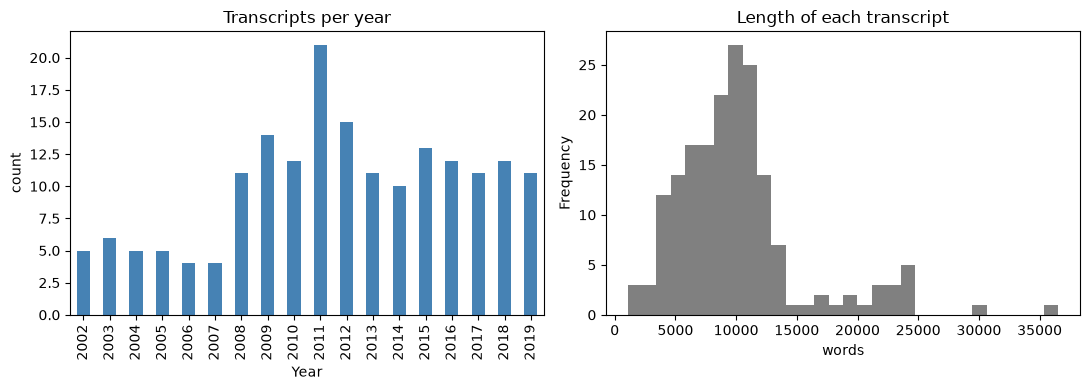

In [4]:
print(len(df), 'transcripts,', df['n_words'].sum(), 'words')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df.groupby('Year').size().plot.bar(ax=ax[0], color='steelblue')
ax[0].set_title('Transcripts per year'); ax[0].set_ylabel('count')
df['n_words'].plot.hist(bins=30, ax=ax[1], color='grey')
ax[1].set_title('Length of each transcript'); ax[1].set_xlabel('words')
plt.tight_layout(); plt.show()

Keep both panels in mind: the number of transcripts per year varies from 4 to 21, and a single transcript can be anywhere from about 1,000 to 37,000 words. We will need this shortly.

> Note: `len(text)` on a string counts **characters**, not words. `text.split()` breaks it into words first. The 2016 shareholder meeting below is ~125,000 characters but only ~20,000 words; mixing these up is an easy way to be wrong by a factor of 6.

## 2. Regular expressions

A regular expression (regex) is a search pattern for text: Ctrl+F with superpowers. You can try patterns interactively at [regexr.com](https://regexr.com/). A few building blocks:

| pattern | matches |
|---|---|
| `climate change` | that exact phrase |
| `climate change\|global warming` | either phrase (`\|` means OR) |
| `\bcrude\b` | "crude" as a whole word (`\b` = word boundary), not "crudely" |
| `emissions?` | "emission" or "emissions" (`?` = previous character optional) |
| `[^.]*` | any run of characters that are not a full stop |

Let's start with one transcript: the **2016 annual shareholder meeting**, chaired by then-CEO Rex Tillerson (a year later he was US Secretary of State).

In [5]:
call = df.iloc[38]
print(call['Title'], '|', call['Date'].date(), '|', call['n_words'], 'words')
print(call['Text'][:600])

Exxon  Mobil Corp Annual Shareholders Meeting - Final | 2016-05-25 | 20410 words
I'm Rex Tillerson, I'm the Chairman and Chief Executive Officer of the Exxon Mobil Corporation. And I am pleased to welcome each of you that made the effort to join us today in person. I also, though, want to welcome our shareholders around the world who are joining us by way of the Internet.

I do hope you had the opportunity to meet some of our employees in person while visiting the displays in the foyer this morning. These Exxon Mobil employees are among the over 73,000 people who are working 24 hours a day, seven days a week, 365 days a year on your behalf. And many of them are working in 


In [6]:
# re.findall returns a list of every match; its length is the count
mentions = re.findall(r'climate change', call['Text'], flags=re.IGNORECASE)
len(mentions)

51

### Exercise: counting phrases

How many times does this meeting mention "global warming"? And "carbon" as a whole word? Then write **one** pattern that counts "emission" and "emissions" together.

In [7]:
# your code here

### Applying a pattern to every transcript

`.apply(lambda x: ...)` runs a small function on every value of a column. Here `x` is the text of one transcript:

In [8]:
df['climate_mentions'] = df['Text'].apply(lambda x: len(re.findall(r'climate change', x, flags=re.IGNORECASE)))
df[['Date', 'Title', 'climate_mentions']].sort_values('climate_mentions', ascending=False).head()

,Date,Title,climate_mentions
38,2016-05-25,Exxon Mobil Corp Annual Shareholders Meeting - Final,51
168,2004-05-26,ExxonMobil Corporation Shareholders Meeting - Final,33
4,2019-05-29,Exxon Mobil Corp Annual Shareholders Meeting - Final,25
63,2014-05-28,Exxon Mobil Corporation Annual Shareholder Meeting - Final,22
156,2007-05-30,Exxon Mobil Corporation Shareholders Meeting - Final,21


## 3. Spot the problem: counts are not rates

A colleague sends you this chart with the message: *"Exxon's climate talk tripled between 2007 and 2016 (21 mentions to 64). Something changed!"*

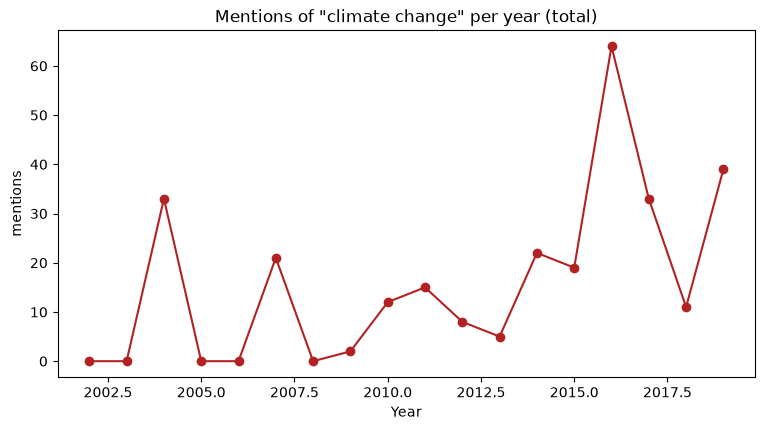

In [9]:
yearly = df.groupby('Year')['climate_mentions'].sum()
yearly.plot(marker='o', color='firebrick')
plt.title('Mentions of "climate change" per year (total)')
plt.ylabel('mentions'); plt.show()

### Exercise: diagnose and fix

1. Look back at the two panels in Section 1. Give **two** reasons why a yearly *total* of mentions is a misleading measure of how much Exxon "talked about" climate change.
2. Compute a better measure, **mentions per 10,000 words** for each year (hint: sum the mentions and the words per year, *then* divide) and plot it next to the original. Does the colleague's claim survive?
3. Sort `df` by `climate_mentions`. How much of the 2016 total comes from a single transcript? Even with rates, *who* is doing the talking? Keep that question in mind for Section 6.

In [10]:
# your code here

### Pulling out whole sentences

Counting tells us *how often*; to see *what was said* we need context. A crude but useful trick is to split the whole corpus into sentences at `.`, `?` or `!` followed by a space, and keep those matching a pattern. (spaCy does sentence segmentation properly, but it would take several minutes on 11 million characters.)

In [11]:
all_text = ' '.join(df['Text'])
sentences = [s.strip() for s in re.split(r'(?<=[.?!])\s+', all_text)]
sentences = [s for s in sentences if 5 <= len(s.split()) <= 60]   # drop fragments and run-ons
print(len(sentences), 'sentences')

def find_sentences(pattern):
    rx = re.compile(pattern, flags=re.IGNORECASE)
    return [s for s in sentences if rx.search(s)]

climate_sentences = find_sentences(r'\bclimate change\b')
print(len(climate_sentences), 'sentences mention climate change, e.g.:\n')
for s in climate_sentences[100:105]:
    print('-', s)

93343 sentences


262 sentences mention climate change, e.g.:

- Continuing to grow high cost fossil fuel reserves in the face of global climate change disruptive agreement is no longer prudent.
- Every day, new reports and incidents demonstrate the importance of the 2-degree target for the sake of our planet for future generations and vulnerable communities, communities hit hardest by climate change.
- Decades have been lost in the fight against climate change due in part to our company's deliberate campaign of disinformation.
- The next shareholder proposal calls for a report on impacts of climate change policies and is shown on Pages 69 and 70 of the proxy statement.
- Chairman, as you have acknowledged this morning, climate change is real.


## 4. The spaCy pipeline: from text to table

`nlp(text)` runs the pipeline from the lecture in one go: **sentence segmentation, tokenisation, part-of-speech tagging, lemmatisation, stop-word flags, dependency parsing** and **named entity recognition**. The result is a `Doc`: a sequence of tokens, each with its annotations attached.

In [12]:
doc = nlp("Standing on the River Thames, London has been a major settlement for two millennia. "
          "It was founded by the Romans, who named it Londinium.")

for i, sent in enumerate(doc.sents):     # 1. sentence segmentation
    print(i, sent)
print([t.text for t in doc][:12])       # 2. tokenisation

0 Standing on the River Thames, London has been a major settlement for two millennia.
1 It was founded by the Romans, who named it Londinium.
['Standing', 'on', 'the', 'River', 'Thames', ',', 'London', 'has', 'been', 'a', 'major', 'settlement']


Each token carries its annotations as attributes. Putting them into a DataFrame gives us the lecture's **text to table** step: from here on, it's just pandas.

In [13]:
def doc_to_table(doc):
    return pd.DataFrame({
        'token':  [t.text for t in doc],
        'lemma':  [t.lemma_ for t in doc],   # dictionary form: 'was' -> 'be', 'named' -> 'name'
        'pos':    [t.pos_ for t in doc],     # part of speech
        'stop':   [t.is_stop for t in doc],  # stop word?
        'dep':    [t.dep_ for t in doc],     # grammatical relation to its head
        'head':   [t.head.text for t in doc],# the word it depends on
        'entity': [t.ent_type_ for t in doc],
    })

doc_to_table(doc)

,token,lemma,pos,stop,dep,head,entity
0,Standing,stand,VERB,False,advcl,been,
1,on,on,ADP,True,prep,Standing,
2,the,the,DET,True,det,Thames,
3,River,River,PROPN,False,compound,Thames,
4,Thames,Thames,PROPN,False,pobj,on,
5,",",",",PUNCT,False,punct,been,
6,London,London,PROPN,False,nsubj,been,GPE
7,has,have,AUX,True,aux,been,
8,been,be,AUX,True,ROOT,been,
9,a,a,DET,True,det,settlement,


The dependency parse is a tree: every word points to a "head" word, and the root is the main verb. Look at the second sentence: **It** is `nsubjpass` (the subject of a *passive* verb), **founded** is the root, and **by the Romans** is the `agent`, the one who actually did the founding.

In [14]:
displacy.render(list(doc.sents)[1], style='dep', jupyter=True, options={'compact': True, 'distance': 95})

The same tables work at scale. Here are the parts of speech across 300 of Exxon's climate sentences. `nlp.pipe` processes many texts efficiently, and we switch off components we don't need to save time:

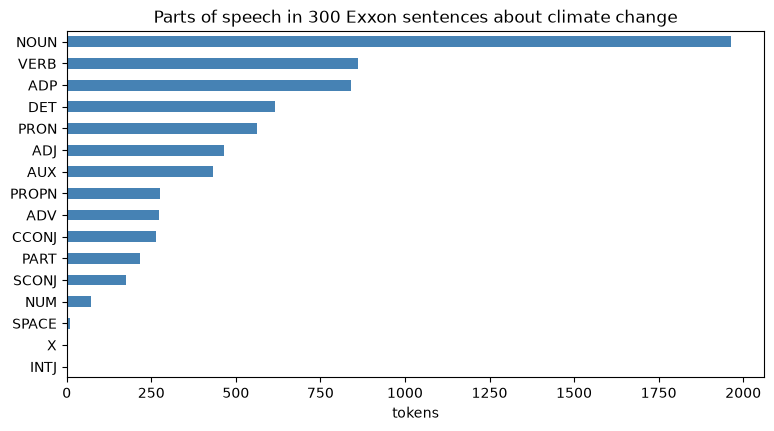

In [15]:
pos_counts = Counter()
for d in nlp.pipe(climate_sentences[:300], disable=['ner', 'spacytextblob']):
    pos_counts.update(t.pos_ for t in d if not t.is_punct)

pd.Series(pos_counts).sort_values().plot.barh(color='steelblue')
plt.title('Parts of speech in 300 Exxon sentences about climate change'); plt.xlabel('tokens'); plt.show()

### Exercise: explore the pipeline

Pick any sentence from `climate_sentences`, run it through `nlp`, and display it with `doc_to_table` and `displacy.render`.

1. What is the root verb, and what is its subject (`nsubj` or `nsubjpass`)?
2. Find one token where spaCy's tag looks wrong to you. Remember that the tagger is a statistical model trained on other text, not a grammar rulebook.
3. Which named entities (`doc.ents`) does it find?

In [16]:
# your code here

## 5. The grammar of agency

The lecture's study ([Moreno-Medina et al. 2022](https://www.nber.org/system/files/working_papers/w30209/w30209.pdf)) coded news sentences about police killings by *how much responsibility the grammar assigns to the officer*. Relative to the active sentence "police officer killed man", they looked at four ways of obscuring it:

In [17]:
examples = pd.DataFrame({
    'construction': ['active', 'passive', 'no agent', 'nominalisation', 'intransitive'],
    'sentence': ['Police officer killed man.',
                 'Man was killed by police officer.',
                 'Man was killed.',
                 'A deadly officer-involved shooting occurred.',
                 'Man dies in shooting.'],
})
examples

,construction,sentence
0,active,Police officer killed man.
1,passive,Man was killed by police officer.
2,no agent,Man was killed.
3,nominalisation,A deadly officer-involved shooting occurred.
4,intransitive,Man dies in shooting.


The dependency labels give us most of what we need to detect these automatically:

- `nsubj`: subject of an active verb (the do-er)
- `nsubjpass` + `auxpass`: passive voice ("man **was** killed")
- `agent`: the "by ..." phrase that names who did it in a passive sentence

Let's write a function that turns a sentence into a row describing its agency.

In [18]:
def agency(doc):
    root = [t for t in doc if t.dep_ == 'ROOT'][0]
    subj = [t for t in root.children if t.dep_ in ('nsubj', 'nsubjpass')]
    agent = [t for t in doc if t.dep_ == 'agent']
    passive = any(t.dep_ == 'nsubjpass' for t in doc)
    return {
        'root_verb': root.lemma_,
        'subject': subj[0].text if subj else None,
        'passive': passive,
        'agentless_passive': passive and not agent,
        'agent': ' '.join(t.text for t in agent[0].subtree) if agent else None,
    }

examples.join(pd.DataFrame([agency(nlp(s)) for s in examples['sentence']]))

,construction,sentence,root_verb,subject,passive,agentless_passive,agent
0,active,Police officer killed man.,kill,officer,False,False,NaN
1,passive,Man was killed by police officer.,kill,Man,True,False,by police officer
2,no agent,Man was killed.,kill,Man,True,True,NaN
3,nominalisation,A deadly officer-involved shooting occurred.,occur,shooting,False,False,NaN
4,intransitive,Man dies in shooting.,die,Man,False,False,NaN


The detector catches active vs passive vs agentless passive. But look at the last two rows: grammatically, the subject of the nominalisation sentence is "shooting" and of the intransitive one is "Man". Our detector sees nothing wrong with either, even though the officer has vanished. **A measurement is only as good as its definition**: the paper had to build extra rules for these cases.

### Exercise: test the detector

Write five headlines of your own about an event with a clear actor (for example a ship hitting a pier, a company laying off workers, or a government cutting a budget), using each of the five constructions above. Run them through `agency()`.

1. Which constructions does it classify correctly?
2. Can you write a sentence that **fools** it: passive in meaning but not flagged, or flagged as passive when an actor is clearly named?

In [19]:
my_headlines = [
    # 'Tanker hits pier.',
]
# pd.DataFrame([agency(nlp(s)) for s in my_headlines])

### Does Exxon use the passive voice when things go wrong?

Now we can ask the lecture's question of our own corpus. Do Exxon's transcripts describe **incidents** (spills, leaks, accidents) with less agency than they describe **earnings**? We'll compare topics on three measures: the share of sentences that are passive, agentless passive, and that have "we" as the active subject.

In [20]:
topics = {
    'earnings':  r'\b(earnings|profits?)\b',
    'dividends': r'\b(dividends?|buybacks?)\b',
    'climate':   r'\b(climate change|emissions|greenhouse)\b',
}

def agency_profile(sents, n=400, seed=0):
    rng = np.random.default_rng(seed)
    picks = rng.choice(len(sents), size=min(n, len(sents)), replace=False)
    sample = [sents[i] for i in picks]
    rows = []
    for d in nlp.pipe(sample, disable=['ner', 'spacytextblob']):
        a = agency(d)
        a['we_subject'] = any(t.dep_ == 'nsubj' and t.lower_ == 'we' for t in d)
        rows.append(a)
    return pd.DataFrame(rows)

profiles = {name: agency_profile(find_sentences(p)) for name, p in topics.items()}
summary = pd.DataFrame({name: p[['passive', 'agentless_passive', 'we_subject']].mean()
                        for name, p in profiles.items()}).T
summary['n'] = [len(p) for p in profiles.values()]
summary

,passive,agentless_passive,we_subject,n
earnings,0.0600,0.0225,0.0900,400
dividends,0.0625,0.0600,0.4175,400
climate,0.1075,0.0875,0.3075,400


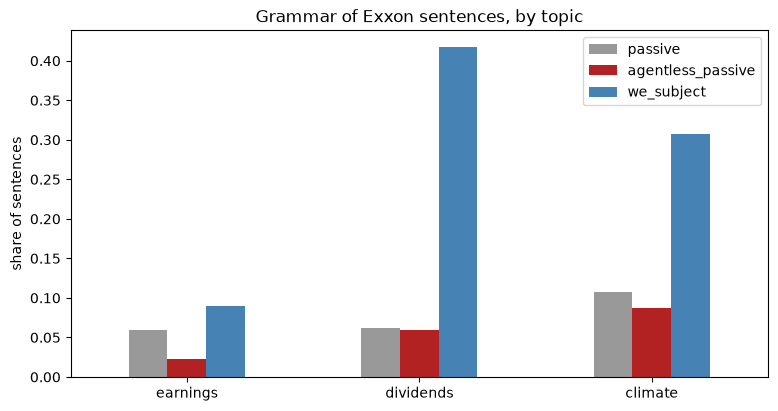

In [21]:
summary[['passive', 'agentless_passive', 'we_subject']].plot.bar(rot=0, color=['#999999', 'firebrick', 'steelblue'])
plt.ylabel('share of sentences'); plt.title('Grammar of Exxon sentences, by topic'); plt.show()

### Exercise: incidents

1. Add an `'incidents'` topic to `topics` (think: spill, leak, incident, accident, fatality... and use `?` for plurals). Rerun the two cells above. How does its grammar compare to earnings and dividends?
2. Print ten of the incident sentences flagged `agentless_passive`. Are they really hiding an actor, or is the passive natural there?
3. Before you believe the gap: how many incident sentences are there compared to earnings sentences? What other differences between the topics (not Exxon's intent) could explain the pattern? What would you need to do to make a claim like the paper's?

In [22]:
# your code here

## 6. Who says what? Distinguishing terms

In the 2016 shareholder meeting, each new speaker is introduced in capitals followed by a colon, e.g. `REX TILLERSON: ` or `NATASHA LAMB, DIRECTOR OF EQUITY RESEARCH, ARJUNA CAPITAL: `. We can use that structure to split the transcript into turns:

- `re.findall(r'([A-Z]+.+[A-Z]+: )', text)` finds the speaker labels
- `re.split(...)` with the same pattern cuts the text at those labels

In [23]:
speaker_rx = r'[A-Z]+.+[A-Z]+: '
speakers = ['INTRODUCTION'] + re.findall(speaker_rx, call['Text'])   # nobody is named before the opening remarks
speech = re.split(speaker_rx, call['Text'])

turns = pd.DataFrame({'speaker': speakers, 'speech': speech})
turns['speaker'] = turns['speaker'].str.replace(':', '').str.strip()
turns['group'] = np.where(turns['speaker'] == 'REX TILLERSON', 'Tillerson', 'Others')
turns['words'] = turns['speech'].str.split().str.len()
print(turns.groupby('group')['words'].sum())
turns[['speaker', 'words']].head(8)

group
Others       10766
Tillerson     9419
Name: words, dtype: int64


,speaker,words
0,INTRODUCTION,712
1,"JEFF WOODBURY, VP OF INVESTOR RELATIONS, CORPORATE SECRETARY, EXXONMOBIL CORPORATION",999
2,REX TILLERSON,5245
3,REX TILLERSON,281
4,REX TILLERSON,426
5,"BETH RICHTMAN, INVESTMENT MANAGER, CALPERS",476
6,REX TILLERSON,55
7,"MICHAEL CROSBY, CAPUCHIN FRANCISCAN FRIAR",470


Which words does Tillerson use much more than the shareholders who question him, and vice versa? We count **lemmas** (so "invest", "invested", "investing" count together), drop stop words and punctuation, convert counts to **rates per 1,000 words** (the two groups spoke different amounts), and rank by the **log ratio** of the rates. We add 0.5 to every count so words used by only one group don't cause a division by zero.

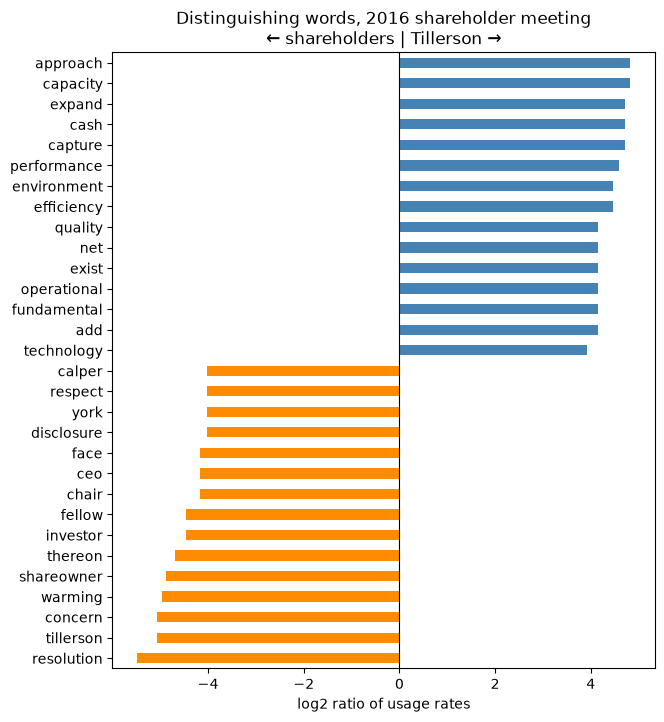

In [24]:
def lemma_counts(texts):
    c = Counter()
    for d in nlp.pipe(texts, disable=['ner', 'parser', 'spacytextblob']):
        c.update(t.lemma_.lower() for t in d if t.is_alpha and not t.is_stop and len(t) > 2)
    return c

freq = pd.DataFrame({g: lemma_counts(turns.loc[turns['group'] == g, 'speech']) for g in ['Tillerson', 'Others']}).fillna(0)
freq = freq[freq.sum(axis=1) >= 8]                        # ignore rare words
rates = (freq + 0.5) / (freq + 0.5).sum() * 1000          # per 1,000 counted words
freq['log_ratio'] = np.log2(rates['Tillerson'] / rates['Others'])
top = pd.concat([freq.nsmallest(15, 'log_ratio'), freq.nlargest(15, 'log_ratio')]).sort_values('log_ratio')

top['log_ratio'].plot.barh(figsize=(7, 8), color=np.where(top['log_ratio'] > 0, 'steelblue', 'darkorange'))
plt.axvline(0, color='k', lw=0.8)
plt.title('Distinguishing words, 2016 shareholder meeting\n← shareholders | Tillerson →')
plt.xlabel('log2 ratio of usage rates'); plt.show()

### Exercise: read the room

1. What do the two ends of the chart tell you about the agenda of each side?
2. Find the sentences where "ALEC" is mentioned (use a regex on `call['Text']`). What is ALEC, what did shareholders want, and how does Tillerson respond?
3. Why did we use rates and a log ratio rather than simply "Tillerson's most common words"?

In [25]:
# your code here

## 7. Sentiment analysis

Lexicon-based sentiment gives every word in a dictionary a **polarity** (−1 negative to +1 positive) and a **subjectivity** (0 factual to 1 opinion), then averages the words it finds. `spacytextblob` adds this to every spaCy `Doc`:

- `doc._.blob.polarity`, `doc._.blob.subjectivity`
- `doc._.blob.sentiment_assessments.assessments`: *which* words drove the score. Always look at this.

We'll use a year of tweets containing **#ExxonKnew** (2016), the hashtag of the campaign over what Exxon knew about climate change.

In [26]:
tweets = pd.read_csv('https://storage.googleapis.com/qm2/wk4/Exxon_tweets_clean.csv')
tweets['created_at'] = pd.to_datetime(tweets['created_at'], errors='coerce', utc=True)
tweets = tweets.dropna(subset=['created_at', 'text'])
print(len(tweets), 'tweets;', round(tweets['text'].str.startswith('RT @').mean() * 100), '% are retweets')
tweets[['created_at', 'author_id', 'text']].head()

89079 tweets; 65 % are retweets


,created_at,author_id,text
0,2016-12-31 22:45:29+00:00,22220344,#ClimateChangeIsReal #climateChange #PutinPuppet #ExxonKnew #RESISTANCE https://t.co/l5IxnYCrg2
1,2016-12-31 22:42:18+00:00,31413260,What you should know about @latimes connections to the debunked #exxonknew campaign https://t.co/xm4zQWjz7A #exxonmo...
2,2016-12-31 22:17:33+00:00,7.59E+17,RT @EnergyInDepth: Legal experts say attack on Exxon sets a “dangerous” precedent https://t.co/6WEALxMBBY #ExxonKnew...
3,2016-12-31 21:40:05+00:00,8.00E+17,"RT @anneli8012: @Khanoisseur yep, Exxon knew about Russia mobster ties this is illegitimate peotus who shld be in ja..."
4,2016-12-31 20:05:36+00:00,7.50E+17,Former NY AG: N.Y.’s ExxonMobil overreach https://t.co/HoT2m2wvCr #ExxonKnew #1A


In [27]:
text = tweets.iloc[130]['text']
d = nlp(text)
print(text)
print('Polarity:', round(d._.blob.polarity, 2), '| Subjectivity:', round(d._.blob.subjectivity, 2))
d._.blob.sentiment_assessments.assessments

RT @Exxon_Knew: Stop saying #Tillerson is good on climate. He leads the oil company WORST on climate #ExxonKnew via @jacobwe https://t.co/P…
Polarity: -0.15 | Subjectivity: 0.8


[(['good'], 0.7, 0.6000000000000001, None), (['worst'], -1.0, 1.0, None)]

The tweet is clearly hostile to Tillerson, and "worst" (−1.0) pulls it negative. But "good" (+0.7) pulls it back up, even though the tweet says *stop saying* he's good. The lexicon has no idea about negation-at-a-distance or who is being quoted.

Let's score a random sample of 5,000 tweets and look at the distribution and the trend over the year.

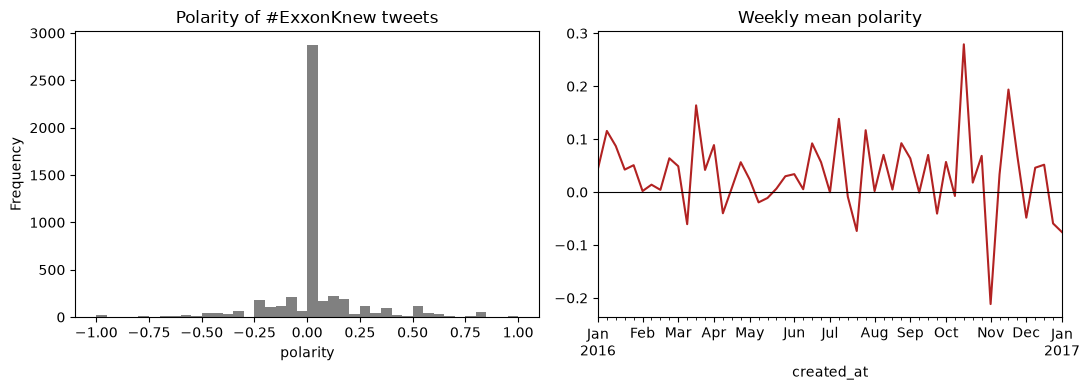

share scored exactly 0: 0.52


In [28]:
sample = tweets.sample(5000, random_state=42).copy()
docs = list(nlp.pipe(sample['text'], disable=['ner', 'parser']))
sample['polarity'] = [d._.blob.polarity for d in docs]
sample['subjectivity'] = [d._.blob.subjectivity for d in docs]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sample['polarity'].plot.hist(bins=40, ax=ax[0], color='grey')
ax[0].set_title('Polarity of #ExxonKnew tweets'); ax[0].set_xlabel('polarity')
sample.set_index('created_at').resample('W')['polarity'].mean().plot(ax=ax[1], color='firebrick')
ax[1].axhline(0, color='k', lw=0.8); ax[1].set_title('Weekly mean polarity')
plt.tight_layout(); plt.show()
print('share scored exactly 0:', round((sample['polarity'] == 0).mean(), 2))

Two things to notice: a large share of tweets score exactly **0** (the lexicon found no words it knows, which is not the same as "neutral"), and the mean is **positive**, for a protest hashtag.

### Exercise: most positive tweets

Sort `sample` by polarity and read the 10 *most positive* tweets. How many are genuinely positive about Exxon? Classify the failures: sarcasm, positive words about *someone else* (e.g. praising a journalist or a lawsuit), or something else?

In [29]:
# your code here

## 8. Spot the problem: a lexicon that doesn't speak oil

An analyst runs the same lexicon on Exxon's transcripts and writes: *"Management's tone was markedly more negative in 2002 and in calls dominated by talk of crude, a sign of anxiety about the core business."*

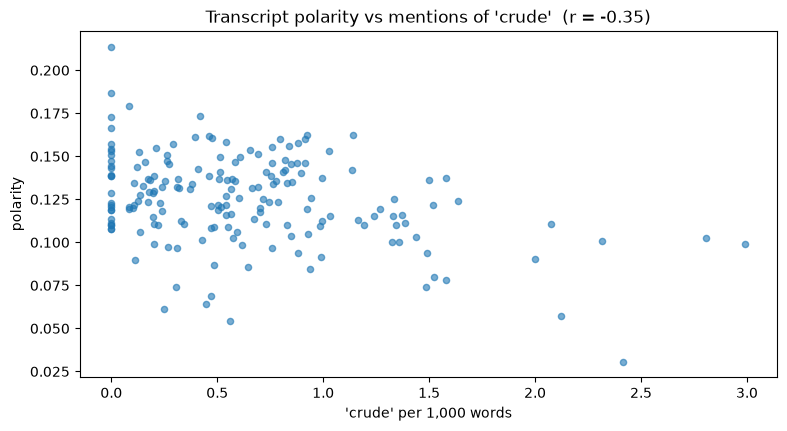

In [30]:
from textblob import TextBlob   # spacytextblob's engine; calling it directly is much faster on long texts

df['polarity'] = df['Text'].apply(lambda x: TextBlob(x).polarity)
df['crude_per_1k'] = df['Text'].apply(lambda x: len(re.findall(r'\bcrude\b', x, flags=re.IGNORECASE))) / df['n_words'] * 1000

df.plot.scatter(x='crude_per_1k', y='polarity', alpha=0.6)
plt.title(f"Transcript polarity vs mentions of 'crude'  (r = {df['crude_per_1k'].corr(df['polarity']):.2f})")
plt.xlabel("'crude' per 1,000 words"); plt.show()

### Exercise: diagnose it

1. Score the sentence `"Crude production was up this quarter."` and look at its `sentiment_assessments`. What is going on?
2. Replace every "crude" with "oil" in the transcripts, recompute polarity, and redraw the scatter. What happens to the correlation?
3. The lexicon was built mostly from product and film reviews. Name two other words common in an oil company's calls that it may misread (hint: think about "heavy", "light", "sweet", "sour" crude, or "lower costs"). Test them.
4. What would you need before trusting *any* sentiment score on a new domain?

In [31]:
# your code here

## 9. Embeddings: words as vectors

Counting words treats "ship" and "boat" as unrelated columns (one-hot encoding: every word is equally different from every other). An **embedding** gives each word a short list of numbers learned from the contexts it appears in ("you shall know a word by the company it keeps"), so that similar words end up with similar vectors.

We'll use the same model as the lecture: **GloVe** (Pennington, Socher & Manning 2014), 100-dimensional vectors trained on Wikipedia and newswire. To keep the download small I've saved the 100,000 most common words (~20 MB).

In [32]:
urllib.request.urlretrieve('https://storage.googleapis.com/qm2/2627/w04/glove100_100k.npz', 'glove100_100k.npz')
g = np.load('glove100_100k.npz')
words = list(g['words'])
vectors = g['vectors'].astype(np.float32)
index = {w: i for i, w in enumerate(words)}   # word -> row number

def vec(w):
    return vectors[index[w]]

print(vectors.shape)
print('ship =', vec('ship')[:8].round(2), '...')

(100000, 100)
ship = [-0.22 -0.12  0.15 -0.22 -0.36 -0.89  0.45  0.04] ...


No single number means anything on its own; the meaning is in the pattern. Compare the three vectors below as heatmaps: "ship" and "boat" share a pattern that "banana" doesn't.

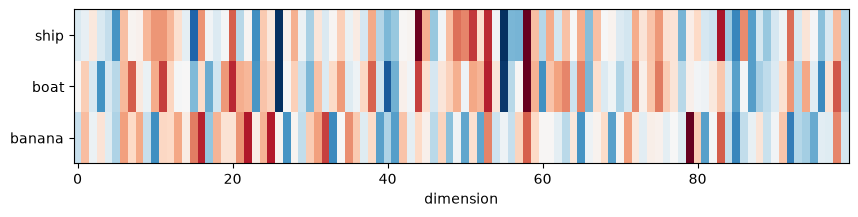

In [33]:
fig, ax = plt.subplots(figsize=(10, 2))
ax.imshow(np.vstack([vec(w) for w in ['ship', 'boat', 'banana']]), aspect='auto', cmap='RdBu_r', vmin=-1.5, vmax=1.5)
ax.set_yticks(range(3), ['ship', 'boat', 'banana']); ax.set_xlabel('dimension'); plt.show()

### Cosine similarity

From the lecture:

$$\cos(a, b) = \frac{a \cdot b}{|a|\,|b|}$$

where $a \cdot b$ = `np.dot(a, b)` (multiply matching elements and sum) and $|a|$ = `np.linalg.norm(a)` (the vector's length).

### Exercise: cosine similarity by hand

Write a function `cosine(a, b)` using only `np.dot` and `np.linalg.norm`. Check it reproduces the lecture's numbers: ship·boat ≈ 0.83, banana·apple ≈ 0.51, ship·banana ≈ 0.18. Then try pairs from today's data: *oil / gas*, *crude / oil*, *climate / weather*, *exxon / chevron*.

In [34]:
def cosine(a, b):
    # your code here
    pass

# cosine(vec('ship'), vec('boat'))

### Nearest neighbours and analogies

To find the words closest to a vector we compare it with **all 100,000** at once. If every row is first scaled to length 1, cosine similarity is just a matrix–vector product.

In [35]:
unit = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)

def nearest(v, n=8, exclude=()):
    sims = unit @ (v / np.linalg.norm(v))
    best = np.argsort(-sims)
    return [(str(words[i]), round(float(sims[i]), 2)) for i in best[:n + len(exclude)] if words[i] not in exclude][:n]

print(nearest(vec('trawler')))
print(nearest(vec('crude')))

[('trawler', 1.0), ('trawlers', 0.79), ('tugboat', 0.73), ('freighter', 0.69), ('vessel', 0.68), ('boat', 0.66), ('fishermen', 0.65), ('estai', 0.65)]
[('crude', 1.0), ('oil', 0.78), ('gasoline', 0.76), ('prices', 0.72), ('barrels', 0.71), ('inventories', 0.7), ('barrel', 0.69), ('stockpiles', 0.67)]


In [36]:
# king - man + woman = ?
nearest(vec('king') - vec('man') + vec('woman'), exclude={'king', 'man', 'woman'})

[('queen', 0.78),
 ('monarch', 0.69),
 ('throne', 0.68),
 ('daughter', 0.68),
 ('prince', 0.67),
 ('princess', 0.66),
 ('mother', 0.66),
 ('elizabeth', 0.66)]

Note the `exclude`: the closest vector to king − man + woman is actually **king** itself; analogy demos quietly drop the input words. The trick is real but less reliable than the headline suggests.

The lecture's plot placed words on two axes computed from the vectors themselves. Let's rebuild it: a **gender** direction (average of female − male pairs) and a **royalty** direction (royal − plain).

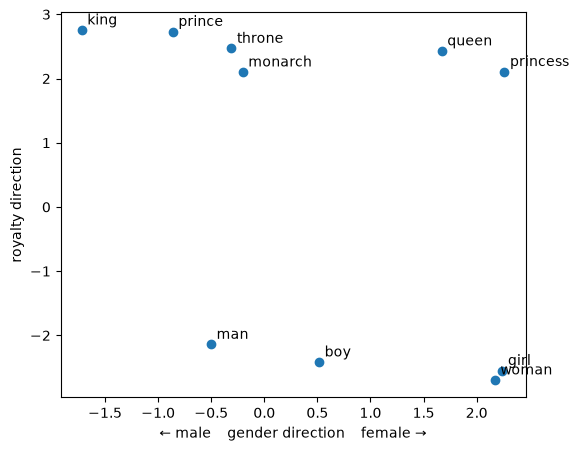

In [37]:
def direction(pairs):
    d = np.mean([vec(a) - vec(b) for a, b in pairs], axis=0)
    return d / np.linalg.norm(d)

gender = direction([('woman', 'man'), ('she', 'he'), ('her', 'his'), ('queen', 'king'), ('daughter', 'son')])
royal = direction([('king', 'man'), ('queen', 'woman'), ('prince', 'boy'), ('princess', 'girl')])

plot_words = ['king', 'queen', 'man', 'woman', 'prince', 'princess', 'boy', 'girl', 'monarch', 'throne']
xy = np.array([[vec(w) @ gender, vec(w) @ royal] for w in plot_words])
plt.figure(figsize=(6, 5))
plt.scatter(xy[:, 0], xy[:, 1])
for w, (x, y) in zip(plot_words, xy):
    plt.annotate(w, (x, y), xytext=(4, 4), textcoords='offset points')
plt.xlabel('← male    gender direction    female →'); plt.ylabel('royalty direction')
plt.show()

### Exercise: your own analogies

Try three analogies of the form *a − b + c*, e.g. *paris − france + germany*, *trawler − fishing + cargo*, *exxon − oil + ...*. Which work, which fail, and why might they fail?

In [38]:
# your code here

### Embeddings learn our biases too

The same geometry that places *queen* near *king* encodes the stereotypes in its training text. A simple **bias probe**: project occupation words onto the gender direction. Positive means closer to "she/woman", negative closer to "he/man".

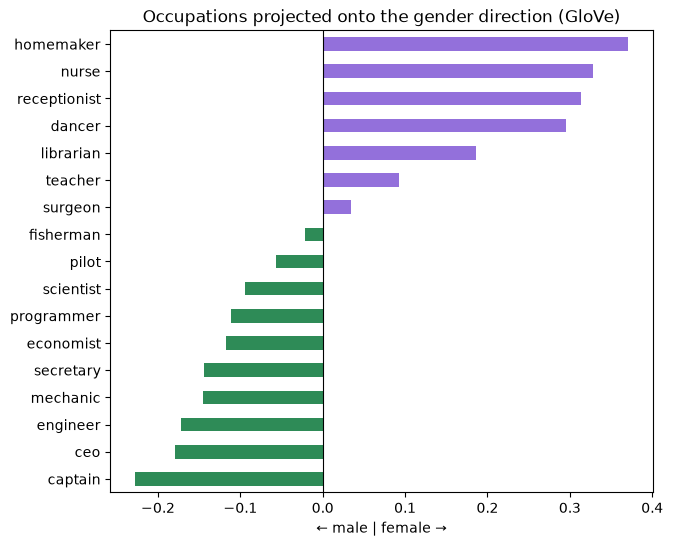

In [39]:
occupations = ['homemaker', 'nurse', 'receptionist', 'librarian', 'teacher', 'dancer', 'secretary',
               'scientist', 'programmer', 'surgeon', 'pilot', 'fisherman', 'mechanic', 'engineer',
               'economist', 'ceo', 'captain']
bias = pd.Series({w: float(unit[index[w]] @ gender) for w in occupations}).sort_values()
bias.plot.barh(color=np.where(bias > 0, 'mediumpurple', 'seagreen'), figsize=(7, 6))
plt.axvline(0, color='k', lw=0.8)
plt.title('Occupations projected onto the gender direction (GloVe)'); plt.xlabel('← male | female →'); plt.show()

### Exercise: probe a different axis

1. Build another direction with `direction()`, e.g. *rich − poor*, or a pair of nationalities, and project a list of words onto it (try words from today's corpus: *shareholder*, *activist*, *environmentalist*, *executive*, *regulator*...).
2. If a company used these embeddings to rank CVs by similarity to "engineer", who would be disadvantaged? What would you ask about the training data before using any embedding in a decision?

In [40]:
# your code here

## 10. Nearest-neighbour search over sentences

Embeddings let us search by **meaning** rather than exact words. The simplest sentence embedding is the **average of its word vectors**, leaving out stop words (otherwise "the", "of" and "we" dominate every average and all sentences look alike). We embed every Exxon sentence about climate, emissions or carbon, embed a query the same way, and return the sentences with the highest cosine similarity.

In [41]:
def embed(text):
    toks = [w for w in re.findall(r"[a-z']+", text.lower()) if w in index and w not in nlp.Defaults.stop_words]
    return np.mean([vec(w) for w in toks], axis=0) if toks else np.zeros(vectors.shape[1], dtype=np.float32)

corpus = find_sentences(r'\b(climate|emissions?|carbon|greenhouse)\b')
corpus_vecs = np.array([embed(s) for s in corpus])
corpus_unit = corpus_vecs / (np.linalg.norm(corpus_vecs, axis=1, keepdims=True) + 1e-9)
print(len(corpus), 'sentences embedded')

def search(query, n=5):
    q = embed(query)
    sims = corpus_unit @ (q / np.linalg.norm(q))
    best = np.argsort(-sims)[:n]
    return pd.DataFrame({'similarity': sims[best].round(3), 'sentence': [corpus[i] for i in best]})

search('we are uncertain about the science')

1309 sentences embedded


,similarity,sentence
0,0.829,No one has still questioned the science on climate change.
1,0.798,"There is a consensus that human activity without question contributes to that risk, but there is also recognition th..."
2,0.796,has been active in climate science for over 30 years.
3,0.795,And I have a question related to Item Nine on transparency and in climate science and policy.
4,0.793,"That is, we use the fundamental sciences of physics, chemistry, geology and biology to model the very complex system..."


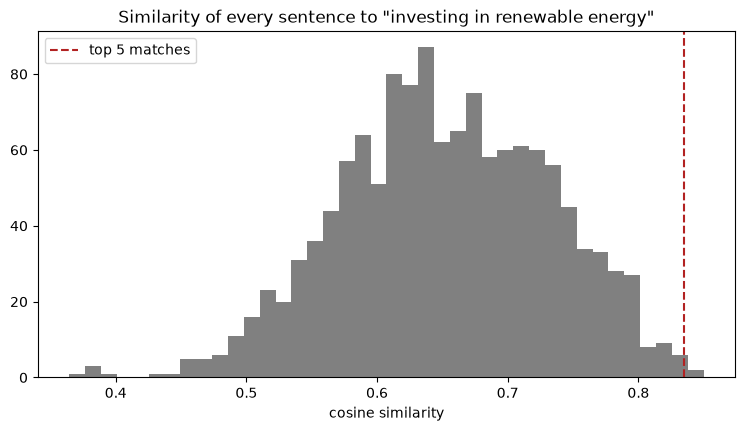

,similarity,sentence
0,0.850,"Since 2004, we have invested $1.9 billion in activities that reduce greenhouse gas emissions and improve our energy ..."
1,0.844,"Investment in cogeneration helps provide reliable power while saving energy, cutting operating costs and reducing gr..."
2,0.836,"We are pioneering science and advancing technologies to improve energy efficiency, reduce emissions and expand the s..."
3,0.836,"Now, let's talk about efficiency and emissions as solutions to the energy challenges."
4,0.835,"And for the oil industry, there are generally four main strategic responses that your competitors are investing in, ..."


In [42]:
query = 'investing in renewable energy'
q = embed(query)
sims = corpus_unit @ (q / np.linalg.norm(q))
plt.hist(sims, bins=40, color='grey')
plt.axvline(np.sort(sims)[-5], color='firebrick', ls='--', label='top 5 matches')
plt.title(f'Similarity of every sentence to "{query}"'); plt.xlabel('cosine similarity'); plt.legend(); plt.show()
search(query)

### Exercise: search and break it

1. Search for a question you would ask Exxon (e.g. *"investing in renewable energy"*, *"the risk of stranded assets"*). Do the results include sentences that **don't** contain your query words? That is what keyword search cannot do.
2. Look at the histogram: are the top matches clearly separated from the rest, or is it a matter of degree? How would you decide how many results to trust?
3. Compute `cosine(embed('we will reduce emissions'), embed('we will not reduce emissions'))`. Explain the result (hint: is "not" a stop word?). Name one more thing an average of word vectors misses (think about word order, or who is the subject: back to Section 5).

In [43]:
# your code here

## (Optional) Extensions

- **Named entities in tweets:** run `nlp.pipe` over the tweet sample, collect `(ent.text, ent.label_)` for `PERSON` and `ORG` entities, and plot the 20 most mentioned. Who are the protagonists of the #ExxonKnew story?
- **Agency by speaker:** combine Sections 5 and 6: do shareholders or Tillerson use more agentless passives in the 2016 meeting?
- **Retweets:** 65% of tweets are retweets. Recompute the weekly polarity using only original tweets. Does it change? Which would you report, and why?

## Wrap-up questions

1. The police-shootings paper says obfuscating grammar changes how readers assign blame. What evidence from today suggests text measures can be **biased by the measuring tool itself** (parser, lexicon, embedding), not only by the writer?
2. For each method today (regex counts, dependency parse, sentiment lexicon, embeddings), name one question it answers well and one trap it sets.

*Data: ExxonMobil earnings call and shareholder meeting transcripts, 2002-2019, compiled for this course; #ExxonKnew tweets, 2016; GloVe 6B vectors (Pennington, Socher & Manning 2014), [nlp.stanford.edu/projects/glove](https://nlp.stanford.edu/projects/glove/).*